# Statistical Baselines: CUSUM (Cumulative Sum)
In this notebook, we implement the CUSUM approach on the three NAB datasets.
We compare the predicted anomalies (using a CUSUM threshold) against the actual known anomaly windows.
We use the first 24 hours (288 data points) to establish the baseline for mean and standard deviation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

# Load the anomaly labels
with open('../data/NAB/labels/combined_windows.json', 'r') as f:
    labels = json.load(f)

# Define baseline window size for 24 hours (5-min intervals: 12 points/hour * 24 hours = 288)
BASELINE_END = 288


## 1. Machine Temperature System Failure
This dataset represents temperature sensor data from an internal component of a large industrial machine. We apply CUSUM to detect persistent small shifts.

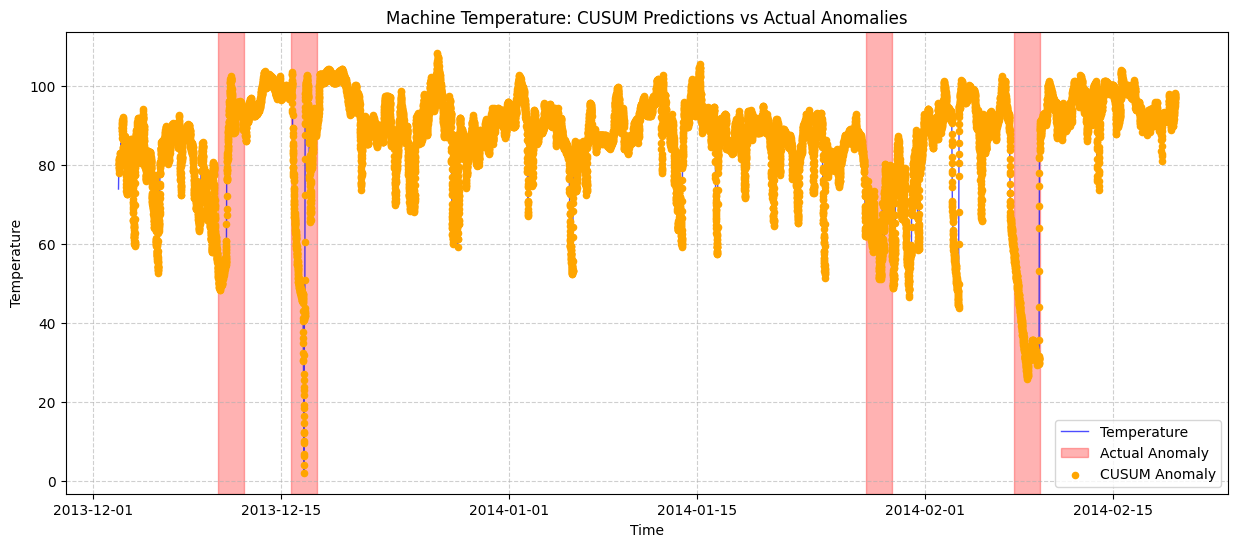

In [2]:
# 1. Machine Temperature System Failure
df1 = pd.read_csv('../data/NAB/data/realKnownCause/machine_temperature_system_failure.csv')
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

# CUSUM implementation
target = df1['value'][:BASELINE_END].mean()
std_dev = df1['value'][:BASELINE_END].std()
k = 0.5 * std_dev  # slack parameter
h = 5 * std_dev    # threshold

cusum_pos, cusum_neg = [0], [0]
for v in df1['value']:
    cusum_pos.append(max(0, cusum_pos[-1] + (v - target) - k))
    cusum_neg.append(max(0, cusum_neg[-1] - (v - target) - k))

df1['cusum_alarm'] = [(p > h or n > h) for p, n in zip(cusum_pos[1:], cusum_neg[1:])]
df1['cusum_alarm'] = df1['cusum_alarm'].astype(int)

# Extract the specific anomaly windows
file_key1 = 'realKnownCause/machine_temperature_system_failure.csv'
anomaly_windows1 = labels.get(file_key1, [])

plt.figure(figsize=(15, 6))
plt.plot(df1['timestamp'], df1['value'], color='blue', linewidth=1, label='Temperature', alpha=0.7)

# Highlight the actual anomaly windows in red
for i, window_val in enumerate(anomaly_windows1):
    start_time = pd.to_datetime(window_val[0])
    end_time = pd.to_datetime(window_val[1])
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

# Highlight CUSUM predictions in orange
anomalies1 = df1[df1['cusum_alarm'] == 1]
plt.scatter(anomalies1['timestamp'], anomalies1['value'], color='orange', s=20, label='CUSUM Anomaly', zorder=5)

plt.title('Machine Temperature: CUSUM Predictions vs Actual Anomalies')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## 2. EC2 CPU Utilization
This dataset contains CPU utilization metrics from an AWS EC2 instance. We apply CUSUM to detect persistent deviations in CPU load.

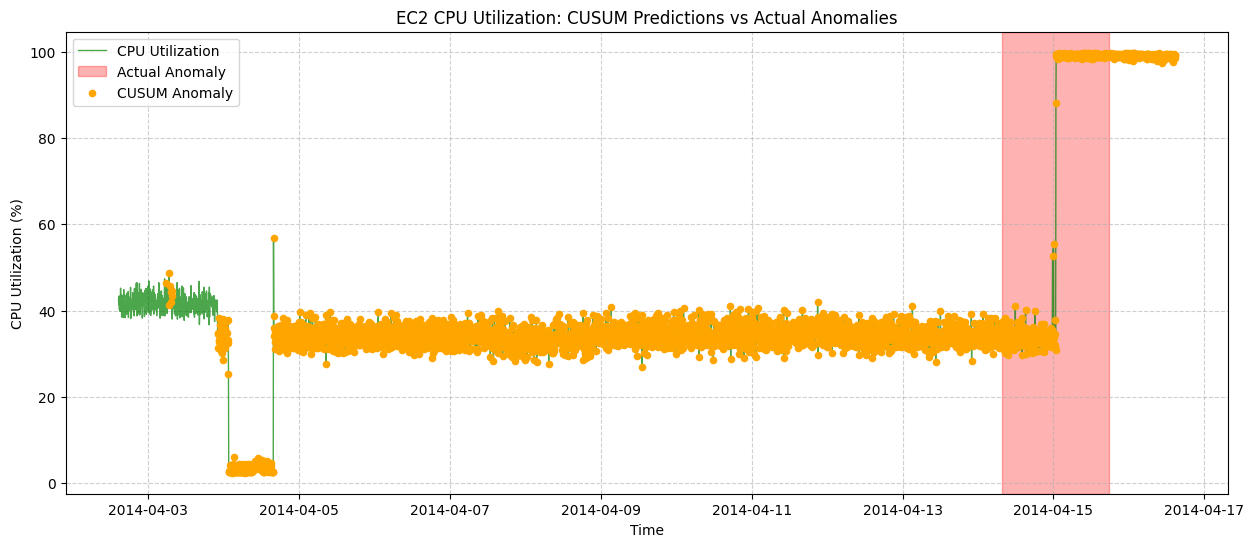

In [3]:
# 2. EC2 CPU Utilization
df2 = pd.read_csv('../data/NAB/data/realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv')
df2['timestamp'] = pd.to_datetime(df2['timestamp'])

# CUSUM implementation
target = df2['value'][:BASELINE_END].mean()
std_dev = df2['value'][:BASELINE_END].std()
k = 0.5 * std_dev  # slack parameter
h = 5 * std_dev    # threshold

cusum_pos, cusum_neg = [0], [0]
for v in df2['value']:
    cusum_pos.append(max(0, cusum_pos[-1] + (v - target) - k))
    cusum_neg.append(max(0, cusum_neg[-1] - (v - target) - k))

df2['cusum_alarm'] = [(p > h or n > h) for p, n in zip(cusum_pos[1:], cusum_neg[1:])]
df2['cusum_alarm'] = df2['cusum_alarm'].astype(int)

# Extract the specific anomaly windows
file_key2 = 'realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv'
anomaly_windows2 = labels.get(file_key2, [])

plt.figure(figsize=(15, 6))
plt.plot(df2['timestamp'], df2['value'], color='green', linewidth=1, label='CPU Utilization', alpha=0.7)

# Highlight the actual anomaly windows in red
for i, window_val in enumerate(anomaly_windows2):
    start_time = pd.to_datetime(window_val[0])
    end_time = pd.to_datetime(window_val[1])
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

# Highlight CUSUM predictions in orange
anomalies2 = df2[df2['cusum_alarm'] == 1]
plt.scatter(anomalies2['timestamp'], anomalies2['value'], color='orange', s=20, label='CUSUM Anomaly', zorder=5)

plt.title('EC2 CPU Utilization: CUSUM Predictions vs Actual Anomalies')
plt.xlabel('Time')
plt.ylabel('CPU Utilization (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## 3. Traffic Speed
This dataset captures traffic speed metrics. We apply CUSUM to identify unexpected shifts in traffic patterns.

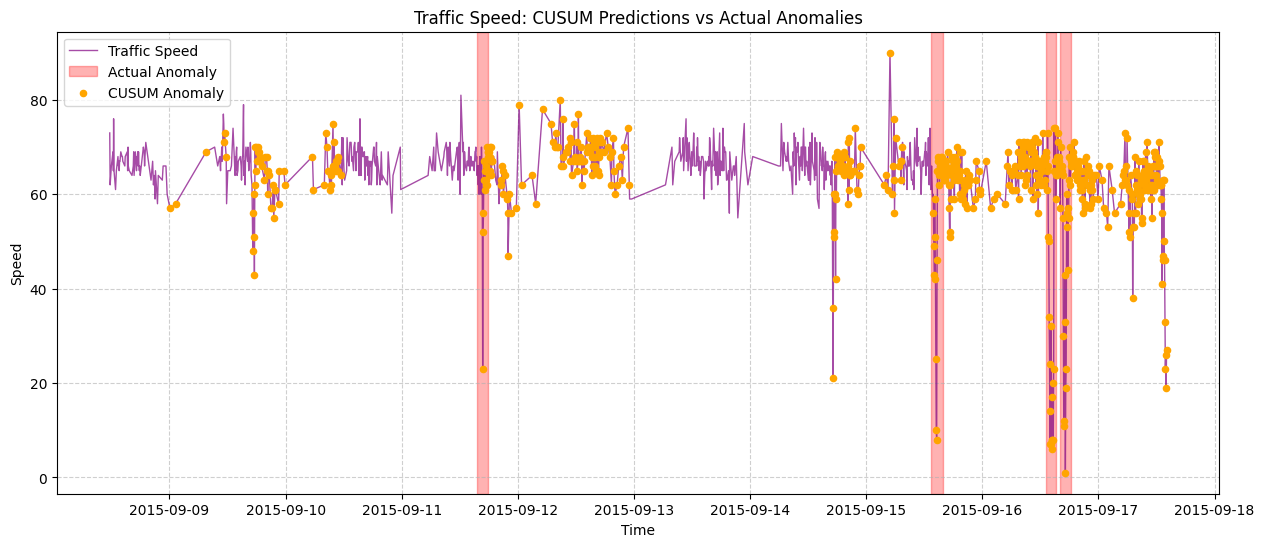

In [4]:
# 3. Traffic Speed
df3 = pd.read_csv('../data/NAB/data/realTraffic/speed_7578.csv')
df3['timestamp'] = pd.to_datetime(df3['timestamp'])

# CUSUM implementation
target = df3['value'][:BASELINE_END].mean()
std_dev = df3['value'][:BASELINE_END].std()
k = 0.5 * std_dev  # slack parameter
h = 5 * std_dev    # threshold

cusum_pos, cusum_neg = [0], [0]
for v in df3['value']:
    cusum_pos.append(max(0, cusum_pos[-1] + (v - target) - k))
    cusum_neg.append(max(0, cusum_neg[-1] - (v - target) - k))

df3['cusum_alarm'] = [(p > h or n > h) for p, n in zip(cusum_pos[1:], cusum_neg[1:])]
df3['cusum_alarm'] = df3['cusum_alarm'].astype(int)

# Extract the specific anomaly windows
file_key3 = 'realTraffic/speed_7578.csv'
anomaly_windows3 = labels.get(file_key3, [])

plt.figure(figsize=(15, 6))
plt.plot(df3['timestamp'], df3['value'], color='purple', linewidth=1, label='Traffic Speed', alpha=0.7)

# Highlight the actual anomaly windows in red
for i, window_val in enumerate(anomaly_windows3):
    start_time = pd.to_datetime(window_val[0])
    end_time = pd.to_datetime(window_val[1])
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

# Highlight CUSUM predictions in orange
anomalies3 = df3[df3['cusum_alarm'] == 1]
plt.scatter(anomalies3['timestamp'], anomalies3['value'], color='orange', s=20, label='CUSUM Anomaly', zorder=5)

plt.title('Traffic Speed: CUSUM Predictions vs Actual Anomalies')
plt.xlabel('Time')
plt.ylabel('Speed')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()
